# 1 Regression

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor

# used random seed 17
X_train = np.load("train_features.npy")
X_valid = np.load("valid_features.npy")
X_test  = np.load("test_features.npy")

print("Feature shapes:")
print("  X_train:", X_train.shape)
print("  X_valid:", X_valid.shape)
print("  X_test :", X_test.shape)

Feature shapes:
  X_train: (1024, 8575)
  X_valid: (256, 8575)
  X_test : (512, 8575)


## Split the labels

In [2]:
# From get_data.ipynb

N_train = X_train.shape[0]
N_valid = X_valid.shape[0]
N_test  = X_test.shape[0]

with fits.open("labels.fits") as hdul:
    labels = hdul[1].data

RGB = True
RGB = np.logical_and(RGB, labels["TEFF"] > 3500.0)
RGB = np.logical_and(RGB, labels["TEFF"] < 5400.0)
RGB = np.logical_and(RGB, labels["LOGG"] < 3.0)
RGB = np.logical_and(RGB, labels["LOGG"] > 0.0)
RGB = np.logical_and(RGB, labels["H"] < 10.5)

RGB_labels = labels[RGB]
N_RGB = len(RGB_labels)

rng = np.random.default_rng(17)
I = rng.permutation(N_RGB)

I_train = I[:N_train]
I_valid = I[N_train:N_train + N_valid]
I_test  = I[N_train + N_valid:N_train + N_valid + N_test]

train_labels = RGB_labels[I_train]
valid_labels = RGB_labels[I_valid]
test_labels  = RGB_labels[I_test]

y_train = np.asarray(train_labels["LOGG"], dtype=np.float64)
y_valid = np.asarray(valid_labels["LOGG"], dtype=np.float64)
y_test  = np.asarray(test_labels["LOGG"], dtype=np.float64)

print("Label shapes:")
print("  y_train:", y_train.shape)
print("  y_valid:", y_valid.shape)
print("  y_test :", y_test.shape)

Label shapes:
  y_train: (1024,)
  y_valid: (256,)
  y_test : (512,)


## Predict LOGG using features

### a) Linear regression

Ridge (VALID): RMSE=0.3938  MAE=0.2355  R2=0.6567
Ridge (TEST) : RMSE=0.3721  MAE=0.2305  R2=0.6995


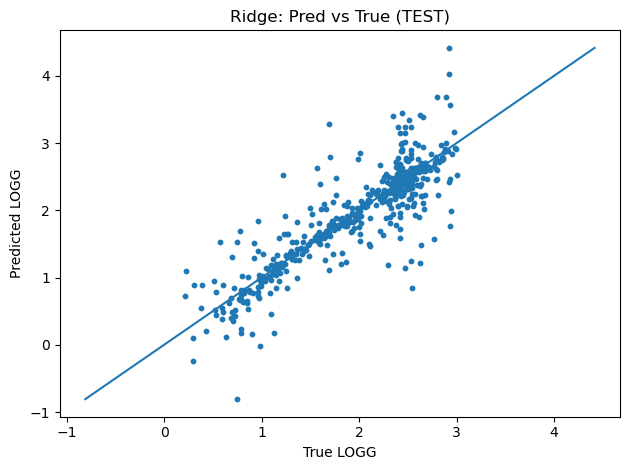

In [3]:
RIDGE_ALPHA = 1.0

ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=RIDGE_ALPHA))
])

ridge_model.fit(X_train, y_train)

pred_valid_ridge = ridge_model.predict(X_valid)
pred_test_ridge  = ridge_model.predict(X_test)

rmse_v = np.sqrt(mean_squared_error(y_valid, pred_valid_ridge))
mae_v  = mean_absolute_error(y_valid, pred_valid_ridge)
r2_v   = r2_score(y_valid, pred_valid_ridge)

rmse_t = np.sqrt(mean_squared_error(y_test, pred_test_ridge))
mae_t  = mean_absolute_error(y_test, pred_test_ridge)
r2_t   = r2_score(y_test, pred_test_ridge)

print("Ridge (VALID): RMSE=%.4f  MAE=%.4f  R2=%.4f" % (rmse_v, mae_v, r2_v))
print("Ridge (TEST) : RMSE=%.4f  MAE=%.4f  R2=%.4f" % (rmse_t, mae_t, r2_t))

plt.figure()
plt.scatter(y_test, pred_test_ridge, s=10)
lo = float(min(np.min(y_test), np.min(pred_test_ridge)))
hi = float(max(np.max(y_test), np.max(pred_test_ridge)))
plt.plot([lo, hi], [lo, hi])
plt.xlabel("True LOGG")
plt.ylabel("Predicted LOGG")
plt.title("Ridge: Pred vs True (TEST)")
plt.tight_layout()
plt.show()

### b) KNN

KNN (VALID): RMSE=0.2425  MAE=0.1557  R2=0.8698
KNN (TEST) : RMSE=0.2491  MAE=0.1666  R2=0.8653


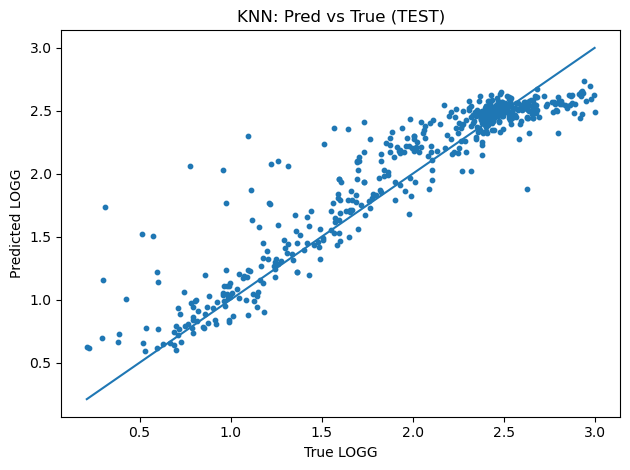

In [4]:
KNN_K = 15

knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsRegressor(n_neighbors=KNN_K, weights="distance"))
])

knn_model.fit(X_train, y_train)

pred_valid_knn = knn_model.predict(X_valid)
pred_test_knn  = knn_model.predict(X_test)

rmse_v = np.sqrt(mean_squared_error(y_valid, pred_valid_knn))
mae_v  = mean_absolute_error(y_valid, pred_valid_knn)
r2_v   = r2_score(y_valid, pred_valid_knn)

rmse_t = np.sqrt(mean_squared_error(y_test, pred_test_knn))
mae_t  = mean_absolute_error(y_test, pred_test_knn)
r2_t   = r2_score(y_test, pred_test_knn)

print("KNN (VALID): RMSE=%.4f  MAE=%.4f  R2=%.4f" % (rmse_v, mae_v, r2_v))
print("KNN (TEST) : RMSE=%.4f  MAE=%.4f  R2=%.4f" % (rmse_t, mae_t, r2_t))

plt.figure()
plt.scatter(y_test, pred_test_knn, s=10)
lo = float(min(np.min(y_test), np.min(pred_test_knn)))
hi = float(max(np.max(y_test), np.max(pred_test_knn)))
plt.plot([lo, hi], [lo, hi])
plt.xlabel("True LOGG")
plt.ylabel("Predicted LOGG")
plt.title("KNN: Pred vs True (TEST)")
plt.tight_layout()
plt.show()

### MLP

MLP (VALID): RMSE=0.6052  MAE=0.4097  R2=0.1894
MLP (TEST) : RMSE=0.5556  MAE=0.3813  R2=0.3302


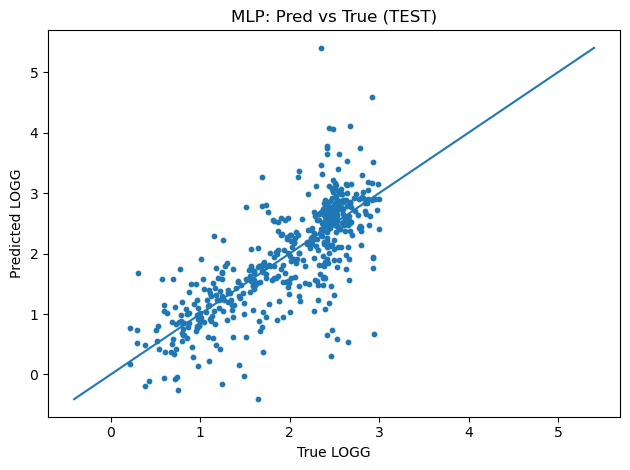

In [5]:
mlp_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPRegressor(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        learning_rate_init=1e-3,
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.15,
        random_state=42
    ))
])

mlp_model.fit(X_train, y_train)

pred_valid_mlp = mlp_model.predict(X_valid)
pred_test_mlp  = mlp_model.predict(X_test)

rmse_v = np.sqrt(mean_squared_error(y_valid, pred_valid_mlp))
mae_v  = mean_absolute_error(y_valid, pred_valid_mlp)
r2_v   = r2_score(y_valid, pred_valid_mlp)

rmse_t = np.sqrt(mean_squared_error(y_test, pred_test_mlp))
mae_t  = mean_absolute_error(y_test, pred_test_mlp)
r2_t   = r2_score(y_test, pred_test_mlp)

print("MLP (VALID): RMSE=%.4f  MAE=%.4f  R2=%.4f" % (rmse_v, mae_v, r2_v))
print("MLP (TEST) : RMSE=%.4f  MAE=%.4f  R2=%.4f" % (rmse_t, mae_t, r2_t))

plt.figure()
plt.scatter(y_test, pred_test_mlp, s=10)
lo = float(min(np.min(y_test), np.min(pred_test_mlp)))
hi = float(max(np.max(y_test), np.max(pred_test_mlp)))
plt.plot([lo, hi], [lo, hi])
plt.xlabel("True LOGG")
plt.ylabel("Predicted LOGG")
plt.title("MLP: Pred vs True (TEST)")
plt.tight_layout()
plt.show()

# 2 Hyperparameter Tuning

### Linear regression

In [6]:
alphas = [1e-4, 1e-2, 1e-1, 1.0, 10.0, 100.0, 1e3]

ridge_results = []
best_ridge = None
best_ridge_rmse = np.inf

for a in alphas:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=a))
    ])
    model.fit(X_train, y_train)
    pred_v = model.predict(X_valid)
    rmse_v = np.sqrt(mean_squared_error(y_valid, pred_v))
    mae_v  = mean_absolute_error(y_valid, pred_v)
    r2_v   = r2_score(y_valid, pred_v)
    ridge_results.append((a, rmse_v, mae_v, r2_v))
    if rmse_v < best_ridge_rmse:
        best_ridge_rmse = rmse_v
        best_ridge = model

print("Ridge tuning (VALID):")
for a, rmse_v, mae_v, r2_v in ridge_results:
    print(f"  alpha={a:<8g}  RMSE={rmse_v:.4f}  MAE={mae_v:.4f}  R2={r2_v:.4f}")

print("\nBest Ridge by VALID RMSE:", [x for x in ridge_results if x[1] == min(r[1] for r in ridge_results)][0][0])

pred_t = best_ridge.predict(X_test)
rmse_t = np.sqrt(mean_squared_error(y_test, pred_t))
mae_t  = mean_absolute_error(y_test, pred_t)
r2_t   = r2_score(y_test, pred_t)
print(f"Best Ridge (TEST): RMSE={rmse_t:.4f}  MAE={mae_t:.4f}  R2={r2_t:.4f}")

Ridge tuning (VALID):
  alpha=0.0001    RMSE=0.4003  MAE=0.2400  R2=0.6454
  alpha=0.01      RMSE=0.4002  MAE=0.2399  R2=0.6455
  alpha=0.1       RMSE=0.3996  MAE=0.2395  R2=0.6466
  alpha=1         RMSE=0.3938  MAE=0.2355  R2=0.6567
  alpha=10        RMSE=0.3586  MAE=0.2123  R2=0.7153
  alpha=100       RMSE=0.2805  MAE=0.1690  R2=0.8258
  alpha=1000      RMSE=0.2327  MAE=0.1549  R2=0.8802

Best Ridge by VALID RMSE: 1000.0
Best Ridge (TEST): RMSE=0.2139  MAE=0.1446  R2=0.9007


### KNN

In [7]:
k_list = [3, 5, 9, 15, 25, 35]
weights_list = ["uniform", "distance"]
p_list = [1, 2]  

knn_results = []
best_knn = None
best_knn_rmse = np.inf
best_knn_cfg = None

for k in k_list:
    for w in weights_list:
        for p in p_list:
            model = Pipeline([
                ("scaler", StandardScaler()),
                ("model", KNeighborsRegressor(n_neighbors=k, weights=w, p=p))
            ])
            model.fit(X_train, y_train)
            pred_v = model.predict(X_valid)
            rmse_v = np.sqrt(mean_squared_error(y_valid, pred_v))
            mae_v  = mean_absolute_error(y_valid, pred_v)
            r2_v   = r2_score(y_valid, pred_v)
            knn_results.append((k, w, p, rmse_v, mae_v, r2_v))
            if rmse_v < best_knn_rmse:
                best_knn_rmse = rmse_v
                best_knn = model
                best_knn_cfg = (k, w, p)

print("KNN tuning (VALID):")
for k, w, p, rmse_v, mae_v, r2_v in knn_results:
    print(f"  k={k:<3d}  weights={w:<8s}  p={p}  RMSE={rmse_v:.4f}  MAE={mae_v:.4f}  R2={r2_v:.4f}")

print("\nBest KNN by VALID RMSE:", best_knn_cfg)

seeds = [0, 1, 2, 3, 4, 5]
k, w, p = best_knn_cfg

boot_valid_rmse = []
boot_test_rmse = []

n_train = X_train.shape[0]
for s in seeds:
    rng = np.random.default_rng(s)
    boot_idx = rng.integers(0, n_train, size=n_train)  # bootstrap sample (with replacement)

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsRegressor(n_neighbors=k, weights=w, p=p))
    ])
    model.fit(X_train[boot_idx], y_train[boot_idx])

    pred_v = model.predict(X_valid)
    pred_t = model.predict(X_test)

    rmse_v = np.sqrt(mean_squared_error(y_valid, pred_v))
    rmse_t = np.sqrt(mean_squared_error(y_test, pred_t))
    boot_valid_rmse.append(rmse_v)
    boot_test_rmse.append(rmse_t)

print("\nKNN bootstrap 'seed reruns' RMSE (VALID):", [round(x, 4) for x in boot_valid_rmse])
print("KNN bootstrap 'seed reruns' RMSE (TEST) :", [round(x, 4) for x in boot_test_rmse])
print(f"KNN RMSE spread (VALID): min={min(boot_valid_rmse):.4f}, max={max(boot_valid_rmse):.4f}")
print(f"KNN RMSE spread (TEST) : min={min(boot_test_rmse):.4f}, max={max(boot_test_rmse):.4f}")

pred_t = best_knn.predict(X_test)
rmse_t = np.sqrt(mean_squared_error(y_test, pred_t))
mae_t  = mean_absolute_error(y_test, pred_t)
r2_t   = r2_score(y_test, pred_t)
print(f"\nBest KNN (TEST, full train): RMSE={rmse_t:.4f}  MAE={mae_t:.4f}  R2={r2_t:.4f}")

KNN tuning (VALID):
  k=3    weights=uniform   p=1  RMSE=0.1922  MAE=0.1287  R2=0.9182
  k=3    weights=uniform   p=2  RMSE=0.2420  MAE=0.1693  R2=0.8704
  k=3    weights=distance  p=1  RMSE=0.1906  MAE=0.1271  R2=0.9196
  k=3    weights=distance  p=2  RMSE=0.2412  MAE=0.1685  R2=0.8713
  k=5    weights=uniform   p=1  RMSE=0.1992  MAE=0.1301  R2=0.9122
  k=5    weights=uniform   p=2  RMSE=0.2281  MAE=0.1529  R2=0.8848
  k=5    weights=distance  p=1  RMSE=0.1969  MAE=0.1287  R2=0.9141
  k=5    weights=distance  p=2  RMSE=0.2278  MAE=0.1525  R2=0.8852
  k=9    weights=uniform   p=1  RMSE=0.2025  MAE=0.1320  R2=0.9092
  k=9    weights=uniform   p=2  RMSE=0.2275  MAE=0.1475  R2=0.8855
  k=9    weights=distance  p=1  RMSE=0.2004  MAE=0.1308  R2=0.9111
  k=9    weights=distance  p=2  RMSE=0.2268  MAE=0.1471  R2=0.8862
  k=15   weights=uniform   p=1  RMSE=0.2075  MAE=0.1346  R2=0.9047
  k=15   weights=uniform   p=2  RMSE=0.2439  MAE=0.1568  R2=0.8684
  k=15   weights=distance  p=1  RMSE=0.205

### MLP

In [8]:
settings = [
    {"hidden_layer_sizes": (64, 64),  "alpha": 1e-4, "learning_rate_init": 1e-3},
    {"hidden_layer_sizes": (128, 64), "alpha": 1e-4, "learning_rate_init": 1e-3},
]
seeds = [0, 1, 2]

best = None
best_mean_rmse = np.inf

for cfg in settings:
    rmses = []
    for s in seeds:
        mlp = Pipeline([
            ("scaler", StandardScaler()),
            ("model", MLPRegressor(
                hidden_layer_sizes=cfg["hidden_layer_sizes"],
                activation="relu",
                solver="adam",
                alpha=cfg["alpha"],
                learning_rate_init=cfg["learning_rate_init"],
                max_iter=300,
                early_stopping=True,
                validation_fraction=0.15,
                random_state=s
            ))
        ])
        mlp.fit(X_train, y_train)
        pred_v = mlp.predict(X_valid)
        rmse_v = np.sqrt(mean_squared_error(y_valid, pred_v))
        rmses.append(rmse_v)

    mean_rmse = float(np.mean(rmses))
    std_rmse  = float(np.std(rmses))
    print(f"cfg={cfg}  VALID RMSE mean±std = {mean_rmse:.4f} ± {std_rmse:.4f}  seeds={list(map(lambda x: round(x,4), rmses))}")

    if mean_rmse < best_mean_rmse:
        best_mean_rmse = mean_rmse
        best = (cfg, mean_rmse, std_rmse)

print("\nBest hyperparameter by mean VALID RMSE:", best[0], "mean±std:", (best[1], best[2]))

cfg={'hidden_layer_sizes': (64, 64), 'alpha': 0.0001, 'learning_rate_init': 0.001}  VALID RMSE mean±std = 0.6905 ± 0.0537  seeds=[0.6505, 0.7664, 0.6546]
cfg={'hidden_layer_sizes': (128, 64), 'alpha': 0.0001, 'learning_rate_init': 0.001}  VALID RMSE mean±std = 0.7075 ± 0.1226  seeds=[0.6989, 0.8618, 0.5619]

Best hyperparameter by mean VALID RMSE: {'hidden_layer_sizes': (64, 64), 'alpha': 0.0001, 'learning_rate_init': 0.001} mean±std: (0.6905112215883715, 0.05371054059064756)


## KNN converges to similar answers. MLP does not.

Predicted LOGG from spectral features using linear regression, K-Nearest Neighbors (KNN), and a Multi-Layer Perceptron (MLP). The dataset was pre-split into training, validation, and test sets.

Hyperparameters were selected based on best validation RMSE.

For linear regression, increasing the regularization strength significantly improved performance. 

For KNN, the hyperparameters tuned are the number of neighbors, weighting scheme, and distance metric. The best configuration was k = 3 with distance weighting and Manhattan distance (p = 1). This model achieved the lowest validation RMSE and highest test R² (≈ 0.92).

For MLP, multiple architectures and random seeds were tested. However, the neural network did not converge to a similar answer across seeds and performed worse than linear regression and KNN. 

# 3 Final Project

Not entirely sure yet but perhaps something related to chromosomes recognitions.